# NEMO2026-style group neuromodulation fitting example

This notebook demonstrates a compact `nmp_modeling` workflow for reproducing the key group-level [NEMO2026](https://www.sciencedirect.com/science/article/pii/S2211124725015888) analysis:

1. select the high-PMAT subgroup from the 971 subjects with REST and all seven tasks;
2. estimate regional Hopf frequencies and fit a group resting-state GEC;
3. combine 19 receptor maps with fitted weights to generate task-specific regional noise;
4. optimize all seven tasks with PSO and compare the predicted task FC/GBC with empirical data.

The example intentionally uses the current project conventions rather than reproducing every [MATLAB](https://github.com/decolab/NR_modulated_whole-brain_computation_captures_full_task-repertoire) implementation detail. In particular, it uses the current GEC constraints, no `i+50` homologue exception, no post-filter trimming, a clean receptor normalization, ordered positive eta bounds, and the simple scikit-image SSIM objective.

Expected local files next to this notebook:

- [`src/`](https://github.com/neich/neuronumba/tree/main/src): local Neuronumba source tree;
- `100/`: HCP Schaefer100 fMRI/order files, `hcp_common_REST1_7tasks_subjects.csv`, and the Schaefer100 7Networks structural connectivity data;
- `HCP_YA_subjects_PMAT.csv`;
- `receptor_data_scale100.csv`.

In [1]:
# Cell 1: path setup and imports
# The local Neuronumba source tree is expected at ./src next to this notebook.

from pathlib import Path
import sys

HERE = Path.cwd().resolve()
DATA_DIR = HERE / "100"
NEURONUMBA_SRC = HERE / "src"
PROJECT_ROOT = next((p for p in [HERE, *HERE.parents] if (p / "nmp_modeling").exists()), None)

if not NEURONUMBA_SRC.exists():
    raise RuntimeError("Expected local Neuronumba source folder at ./src next to this notebook.")
if PROJECT_ROOT is None:
    raise RuntimeError("Could not find project root containing the nmp_modeling package.")

for path in [PROJECT_ROOT, NEURONUMBA_SRC]:
    path = str(path)
    if path not in sys.path:
        sys.path.insert(0, path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from hdf5storage import loadmat
from scipy.special import expit
from skimage.metrics import structural_similarity as ssim

from nmp_modeling.adapters.neuronumba.models.generic_hopf import GenericHopf
from nmp_modeling.hopf.frequency import estimate_peak_frequency
from nmp_modeling.hopf.gec import fit_lagcov_gec
from nmp_modeling.hopf.linear import check_stable_jacobian, linear_fc_from_covariance, make_noise_covariance, solve_stationary_covariance
from nmp_modeling.observable_specs import make_empirical_target
from nmp_modeling.observables import compute_fc, compute_gbc_from_fc, matrix_edges
from nmp_modeling.optimization import optimize
from nmp_modeling.parametrization import FreeParam, WeightedMapParametrization
from nmp_modeling.preprocessing import make_bandpass_filter

print("Project imports completed.")

Project imports completed.


In [2]:
# Cell 2: analysis settings and local file definitions

TR_SECONDS = 0.72
BAND = (0.008, 0.08)
LAG = 3
A_PARAM = -0.01
SIGMA = 0.02
ETA_BOUNDS = (0.001, 0.04)
OPTIMIZER_SEEDS = (101, 202, 303, 404)

FMRI_FILES = {
    "REST1": "hcp_REST1_LR_schaefer100.mat",
    "EMOTION": "hcp_EMOTION_LR_schaefer100.mat",
    "GAMBLING": "hcp_GAMBLING_LR_schaefer100.mat",
    "LANGUAGE": "hcp_LANGUAGE_LR_schaefer100.mat",
    "MOTOR": "hcp_MOTOR_LR_schaefer100.mat",
    "RELATIONAL": "hcp_RELATIONAL_LR_schaefer100.mat",
    "SOCIAL": "hcp_SOCIAL_LR_schaefer100.mat",
    "WM": "hcp_WM_LR_schaefer100.mat",
}
ORDER_FILES = {condition: f"hcporder_{condition}_LR_schaefer100.mat" for condition in FMRI_FILES}
TASKS = ["WM", "GAMBLING", "RELATIONAL", "EMOTION", "MOTOR", "SOCIAL", "LANGUAGE"]
TASK_LABELS = {
    "WM": "WM", "GAMBLING": "Gambling", "RELATIONAL": "Relational",
    "EMOTION": "Emotion", "MOTOR": "Motor", "SOCIAL": "Social", "LANGUAGE": "Language",
}
RECEPTOR_NAMES = [
    "5HT1a", "5HT1b", "5HT2a", "5HT4", "5HT6", "5HTT", "A4B2", "CB1", "D1", "D2",
    "DAT", "GABAa", "H3", "M1", "mGluR5", "MOR", "NET", "NMDA", "VAChT",
]
PAPER_RECEPTORS = [
    ("mGluR5", "mGluR5"), ("5HT1a", "5-HT1A"), ("D2", "D2"), ("5HTT", "5-HTT"),
    ("5HT2a", "5-HT2A"), ("NET", "NET"), ("H3", "H3"), ("5HT1b", "5-HT1B"),
    ("NMDA", "NMDA"), ("A4B2", "A4B2"), ("MOR", "MU"), ("GABAa", "GABA-A"),
    ("M1", "M1"), ("VAChT", "VAChT"), ("5HT6", "5-HT6"), ("D1", "D1"),
    ("CB1", "CB1"), ("DAT", "DAT"), ("5HT4", "5-HT4"),
]

COMMON_FILE = DATA_DIR / "hcp_common_REST1_7tasks_subjects.csv"
SC_FILE = DATA_DIR / "SC_schaefer100_7Networks_32fold_groupconnectome_2mm_symm.mat"
PMAT_FILE = HERE / "HCP_YA_subjects_PMAT.csv"
RECEPTOR_FILE = HERE / "receptor_data_scale100.csv"

required = [COMMON_FILE, SC_FILE, PMAT_FILE, RECEPTOR_FILE]
required += [DATA_DIR / f for f in FMRI_FILES.values()]
required += [DATA_DIR / f for f in ORDER_FILES.values()]
missing = [path for path in required if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required local file(s):\n" + "\n".join(map(str, missing)))

bandpass = make_bandpass_filter(low=BAND[0], high=BAND[1], tr_seconds=TR_SECONDS, remove_artifacts=False)

In [3]:
# Cell 3: load the analysis cohort, structural connectivity, and receptor maps

def extract_ts(cell):
    """Return one subject time series in the project time-by-node convention."""
    ts = np.asarray(cell["schaeferts"][0], dtype=float)
    if ts.ndim != 2 or ts.shape[0] != 100:
        raise ValueError(f"Unexpected time-series shape: {ts.shape}")
    return ts.T.copy()


def load_hcp_condition(condition, subject_ids):
    """Load selected Schaefer100 subjects for one HCP condition."""
    data = loadmat(DATA_DIR / FMRI_FILES[condition], squeeze_me=False)
    subjects = data["subject"][0]
    order = loadmat(DATA_DIR / ORDER_FILES[condition], squeeze_me=False)["order"].ravel().astype(int)
    index = {subject: i for i, subject in enumerate(order)}
    missing = [s for s in subject_ids if s not in index]
    if missing:
        raise ValueError(f"{condition}: subject IDs not found: {missing}")
    timeseries = [extract_ts(subjects[index[int(s)]]) for s in subject_ids]
    return timeseries


common = pd.read_csv(COMMON_FILE)["Subject"].to_numpy(dtype=int)
pmat = pd.read_csv(PMAT_FILE)[["Subject", "PMAT24_A_CR"]].copy()
pmat["Subject"] = pmat["Subject"].astype(int)
cohort = pd.DataFrame({"Subject": common}).merge(pmat, on="Subject", how="left")
q80 = cohort["PMAT24_A_CR"].quantile(0.80)
SUBJECTS = cohort.loc[cohort["PMAT24_A_CR"] > q80, "Subject"].to_numpy(dtype=int)

sc_mat = loadmat(SC_FILE, squeeze_me=True)
SC = np.asarray(sc_mat["SC"], dtype=float)
np.fill_diagonal(SC, 0.0)
if not np.allclose(SC, SC.T) or np.any(SC < 0) or SC.max() <= 0:
    raise ValueError("Unexpected structural connectivity matrix.")

receptors = pd.read_csv(RECEPTOR_FILE, header=None).to_numpy(dtype=float)
if receptors.shape != (100, len(RECEPTOR_NAMES)):
    raise ValueError(f"Unexpected receptor matrix shape: {receptors.shape}")

# Normalize each receptor across parcels: z-score, sigmoid, then min-max to [0, 1].
z = (receptors - receptors.mean(axis=0, keepdims=True)) / receptors.std(axis=0, keepdims=True)
receptors = expit(z)
receptors = (receptors - receptors.min(axis=0, keepdims=True)) / (
    receptors.max(axis=0, keepdims=True) - receptors.min(axis=0, keepdims=True)
)
receptor_maps = {name: receptors[:, i] for i, name in enumerate(RECEPTOR_NAMES)}

density = np.count_nonzero(SC) / (SC.shape[0] * (SC.shape[0] - 1))
print(f"Cohort | common={len(common)} | PMAT q80={q80:g} | selected PMAT>q80={len(SUBJECTS)}")
print(f"Maps   | SC={SC.shape}, density={density:.4f} | receptors={receptors.shape}")

Cohort | common=971 | PMAT q80=21 | selected PMAT>q80=167
Maps   | SC=(100, 100), density=0.9095 | receptors=(100, 19)


Frequency | min=0.0208 Hz | median=0.0220 Hz | max=0.0266 Hz
REST GEC  | best_iter=  52 | best_loss=0.0498557 | FC r=0.4912 | lag r=0.4504 | positive=5712 | stop=loss increased at checkpoint


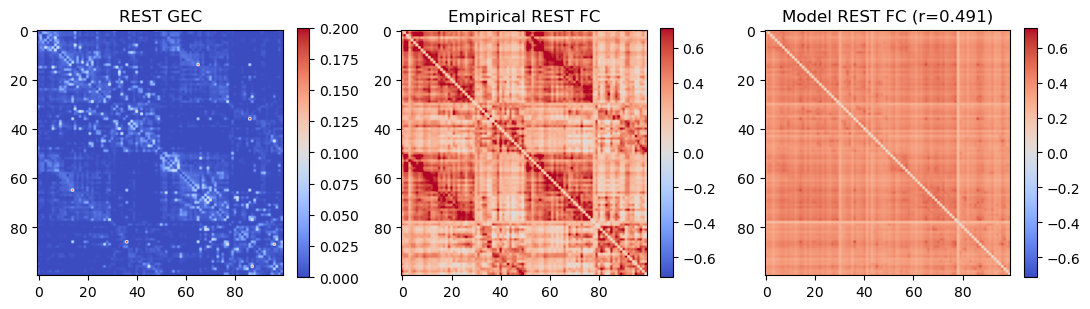

In [4]:
# Cell 4: estimate resting-state frequencies and fit group GEC

REST_TS = np.stack(load_hcp_condition("REST1", SUBJECTS), axis=0)
f_diff = estimate_peak_frequency(REST_TS, tr_seconds=TR_SECONDS, band=BAND)

linear_model = GenericHopf()
linear_model.set_attributes({"a": A_PARAM, "frequency_hz": f_diff})

gec_result = fit_lagcov_gec(
    sc=SC,
    empirical_timeseries=REST_TS,
    lag=LAG,
    tr_seconds=TR_SECONDS,
    linear_model=linear_model,
    sigma=SIGMA,
    preprocess_fn=bandpass,
    learning_rate_lag=0.0004,
    n_iter=5000,
)

C_EFF = np.asarray(gec_result.gec, dtype=float)
rest_fc_emp = np.asarray(gec_result.empirical_fc, dtype=float)
rest_fc_model = np.asarray(gec_result.simulated_fc, dtype=float)
rest_lag_emp = np.asarray(gec_result.empirical_normalized_shifted_covariance, dtype=float)
rest_lag_model = np.asarray(gec_result.simulated_normalized_shifted_covariance, dtype=float)

offdiag = ~np.eye(C_EFF.shape[0], dtype=bool)
fc_r = np.corrcoef(matrix_edges(rest_fc_emp), matrix_edges(rest_fc_model))[0, 1]
lag_r = np.corrcoef(rest_lag_emp[offdiag], rest_lag_model[offdiag])[0, 1]

print(f"Frequency | min={f_diff.min():.4f} Hz | median={np.median(f_diff):.4f} Hz | max={f_diff.max():.4f} Hz")
print(
    f"REST GEC  | best_iter={gec_result.best_iter:4d} | best_loss={gec_result.best_loss:.6g} "
    f"| FC r={fc_r:.4f} | lag r={lag_r:.4f} | positive={np.count_nonzero(C_EFF > 0)} "
    f"| stop={gec_result.stop_reason}"
)

fc_values = np.concatenate([matrix_edges(rest_fc_emp), matrix_edges(rest_fc_model)])
fc_max = np.percentile(np.abs(fc_values), 98)
fc_limits = (-fc_max, fc_max)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for ax, matrix, title, limits in [
    (axes[0], C_EFF, "REST GEC", (0.0, 0.2)),
    (axes[1], rest_fc_emp, "Empirical REST FC", fc_limits),
    (axes[2], rest_fc_model, f"Model REST FC (r={fc_r:.3f})", fc_limits),
]:
    im = ax.imshow(matrix, cmap="coolwarm", vmin=limits[0], vmax=limits[1])
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

del REST_TS

## Exact covariance-basis acceleration

The task PSO changes only the regional noise amplitudes while the fitted GEC and Hopf Jacobian remain fixed. Because the stationary Lyapunov equation is linear in the noise covariance, we can solve one unit-noise covariance per parcel once and reconstruct every later covariance as an exact weighted sum.

This prepares the model for many PSO evaluations: each candidate avoids a new 200×200 Lyapunov solve and instead uses a fast linear combination, while remaining identical to the direct solution up to floating-point precision.

In [5]:
# Cell 5: precompute the exact covariance basis used by task PSO evaluations

N_PARCELS = C_EFF.shape[0]
A = linear_model.get_jacobian(weights=C_EFF, unit="s")
max_real = check_stable_jacobian(A)

COV_BASIS = np.empty((N_PARCELS, N_PARCELS, N_PARCELS), dtype=float)
for i in range(N_PARCELS):
    unit_sigma = np.zeros(N_PARCELS)
    unit_sigma[i] = 1.0
    cov = solve_stationary_covariance(A, make_noise_covariance(unit_sigma, N_PARCELS), check_stability=False)
    COV_BASIS[i] = cov[:N_PARCELS, :N_PARCELS]


def task_fc_from_eta(eta):
    """Compute task FC from the precomputed exact covariance basis."""
    cov_x = np.tensordot(np.asarray(eta, dtype=float) ** 2, COV_BASIS, axes=(0, 0))
    fc = linear_fc_from_covariance(cov_x, N_PARCELS)
    np.fill_diagonal(fc, 0.0)
    return fc


eta_check = np.linspace(0.005, 0.035, N_PARCELS)
direct_cov = solve_stationary_covariance(A, make_noise_covariance(eta_check, N_PARCELS), check_stability=False)
direct_fc = linear_fc_from_covariance(direct_cov, N_PARCELS)
np.fill_diagonal(direct_fc, 0.0)
basis_diff = np.max(np.abs(direct_fc - task_fc_from_eta(eta_check)))

print(f"Covariance basis | max real eig={max_real:.5f} | max |ΔFC|={basis_diff:.3g}")
assert basis_diff < 1e-10

Covariance basis | max real eig=-0.01013 | max |ΔFC|=1.33e-15


In [6]:
# Cell 6: compute empirical group FC for all seven tasks

def load_group_fc(condition):
    """Load, filter, and average FC for one task."""
    timeseries = load_hcp_condition(condition, SUBJECTS)
    lengths = [ts.shape[0] for ts in timeseries]
    fc = np.mean([compute_fc(bandpass(ts)) for ts in timeseries], axis=0)
    return fc, (min(lengths), max(lengths))


TASK_FC = {}
FC_MSE_TARGET = {}

for task in TASKS:
    TASK_FC[task], time_range = load_group_fc(task)
    FC_MSE_TARGET[task] = make_empirical_target(TASK_FC[task], observable="fc_mse", input_type="fc")
    t_text = str(time_range[0]) if time_range[0] == time_range[1] else f"{time_range[0]}-{time_range[1]}"
    print(
        f"{TASK_LABELS[task]:10s} | N={len(SUBJECTS):3d} | T={t_text:>7s} "
        f"| FC edge SD={matrix_edges(TASK_FC[task]).std():.4f}"
    )

WM         | N=167 | T=    405 | FC edge SD=0.1605
Gambling   | N=167 | T=249-253 | FC edge SD=0.1515
Relational | N=167 | T=    232 | FC edge SD=0.1762
Emotion    | N=167 | T=    176 | FC edge SD=0.1461
Motor      | N=167 | T=    284 | FC edge SD=0.1439
Social     | N=167 | T=    274 | FC edge SD=0.1648
Language   | N=167 | T=293-316 | FC edge SD=0.1894


## Receptor-modulated task fitting

`WeightedMapParametrization` turns the 19 receptor maps and their fitted scalar weights into one regional receptor score. Two positive eta endpoints are fitted jointly and sorted so that `eta_min <= eta_max`, removing the global sign ambiguity in the NEMO [MATLAB](https://github.com/decolab/NR_modulated_whole-brain_computation_captures_full_task-repertoire) code.

PSO minimizes a simple SSIM loss for each task. The current project `fc_mse` definition (off-diagonal FC MSE), GBC correlation, and a homogeneous-noise model are reported as diagnostics.

In [7]:
# Cell 7: fit receptor weights and regional noise map eta for every task

receptor_param = WeightedMapParametrization(
    target="receptor_score",
    maps=receptor_maps,
    weight_params=FreeParam(init=0.0, bounds=(-1.0, 1.0)),
)
TASK_FREE_PARAMS = {
    "eta_1": FreeParam(init=0.01, bounds=ETA_BOUNDS),
    "eta_2": FreeParam(init=0.03, bounds=ETA_BOUNDS),
    **receptor_param.free_params,
}


def eta_from_theta(theta):
    """Convert optimized receptor weights and endpoints to regional noise map eta."""
    eta_min, eta_max = sorted((theta["eta_1"], theta["eta_2"]))
    score = receptor_param.evaluate(theta)
    span = np.ptp(score)
    scaled = np.full_like(score, 0.5) if span < 1e-12 else (score - score.min()) / span
    return eta_min + scaled * (eta_max - eta_min), score


BASELINE_FC = task_fc_from_eta(np.full(N_PARCELS, SIGMA))
BASELINE_GBC = compute_gbc_from_fc(BASELINE_FC)
TASK_RESULTS = {}

for task in TASKS:
    empirical_fc = TASK_FC[task]

    def objective(theta):
        eta, _ = eta_from_theta(theta)
        return -float(ssim(empirical_fc, task_fc_from_eta(eta), data_range=2.0))

    runs = [
        optimize(objective, TASK_FREE_PARAMS, method="pso", seed=seed, max_iter=300, population_size=100)
        for seed in OPTIMIZER_SEEDS
    ]
    best = min(runs, key=lambda result: result.best_loss)
    eta, score = eta_from_theta(best.best_theta)
    model_fc = task_fc_from_eta(eta)
    weights = np.array([best.best_theta[f"w_{name}"] for name in RECEPTOR_NAMES])

    emp_gbc = compute_gbc_from_fc(empirical_fc)
    model_gbc = compute_gbc_from_fc(model_fc)
    gbc_r = np.corrcoef(emp_gbc, model_gbc)[0, 1]
    baseline_gbc_r = np.corrcoef(emp_gbc, BASELINE_GBC)[0, 1]
    fc_mse = FC_MSE_TARGET[task].distance(model_fc)

    TASK_RESULTS[task] = {
        "optimizer": best, "weights": weights, "eta": eta, "score": score, "model_fc": model_fc,
        "ssim": -best.best_loss, "fc_mse": fc_mse, "gbc_r": gbc_r,
        "baseline_gbc_r": baseline_gbc_r, "seed": best.seed,
    }

    print(
        f"{TASK_LABELS[task]:10s} | SSIM={-best.best_loss:.4f} | FC MSE={fc_mse:.5f} "
        f"| GBC r={gbc_r:.4f} | baseline={baseline_gbc_r:.4f} "
        f"| eta=[{eta.min():.4f},{eta.max():.4f}] | seed={best.seed}"
    )

gbc_values = np.array([TASK_RESULTS[task]["gbc_r"] for task in TASKS])
baseline_values = np.array([TASK_RESULTS[task]["baseline_gbc_r"] for task in TASKS])
print(
    f"7-task GBC | receptor={gbc_values.mean():.3f} ± {gbc_values.std(ddof=1):.3f} "
    f"| homogeneous={baseline_values.mean():.3f} ± {baseline_values.std(ddof=1):.3f} "
    f"| paper≈0.70 ± 0.06"
)

WM         | SSIM=0.4915 | FC MSE=0.02293 | GBC r=0.7439 | baseline=0.5446 | eta=[0.0067,0.0292] | seed=404
Gambling   | SSIM=0.5103 | FC MSE=0.02137 | GBC r=0.8214 | baseline=0.4319 | eta=[0.0067,0.0322] | seed=404
Relational | SSIM=0.4764 | FC MSE=0.02878 | GBC r=0.7717 | baseline=0.5642 | eta=[0.0074,0.0372] | seed=101
Emotion    | SSIM=0.6006 | FC MSE=0.01699 | GBC r=0.7941 | baseline=0.5049 | eta=[0.0087,0.0394] | seed=101
Motor      | SSIM=0.6317 | FC MSE=0.01860 | GBC r=0.7541 | baseline=0.6931 | eta=[0.0098,0.0280] | seed=101
Social     | SSIM=0.4590 | FC MSE=0.02765 | GBC r=0.6792 | baseline=0.3340 | eta=[0.0079,0.0374] | seed=202
Language   | SSIM=0.4685 | FC MSE=0.03371 | GBC r=0.6197 | baseline=0.3411 | eta=[0.0016,0.0400] | seed=404
7-task GBC | receptor=0.741 ± 0.069 | homogeneous=0.488 ± 0.129 | paper≈0.70 ± 0.06


## Figure 3-style summaries

The first plot follows the receptor-by-task organization of NEMO Figure 3A. The second shows the Figure 3D-style regional GBC prediction for all seven tasks, together with the homogeneous-noise baseline.

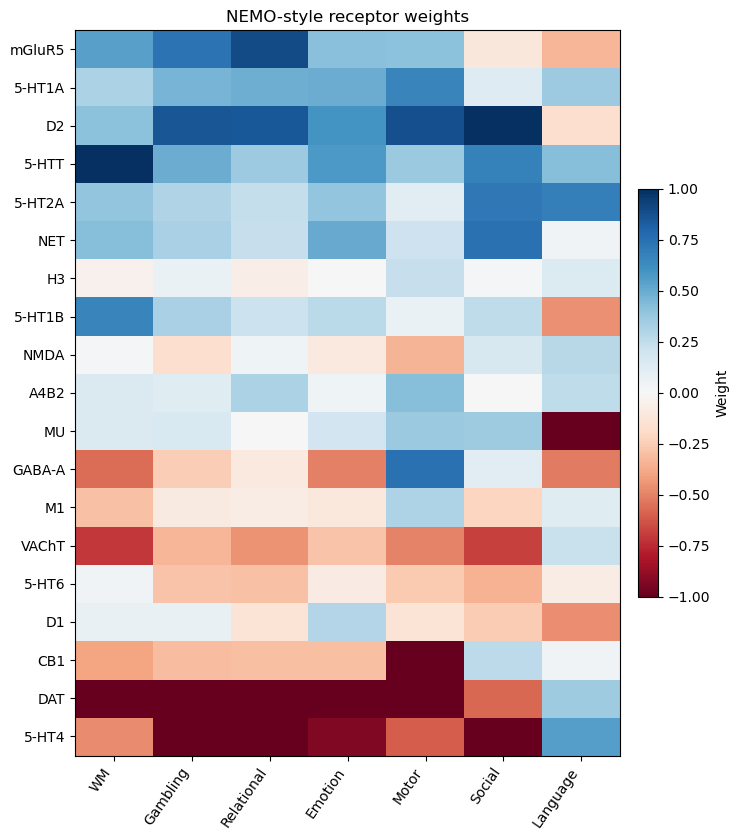

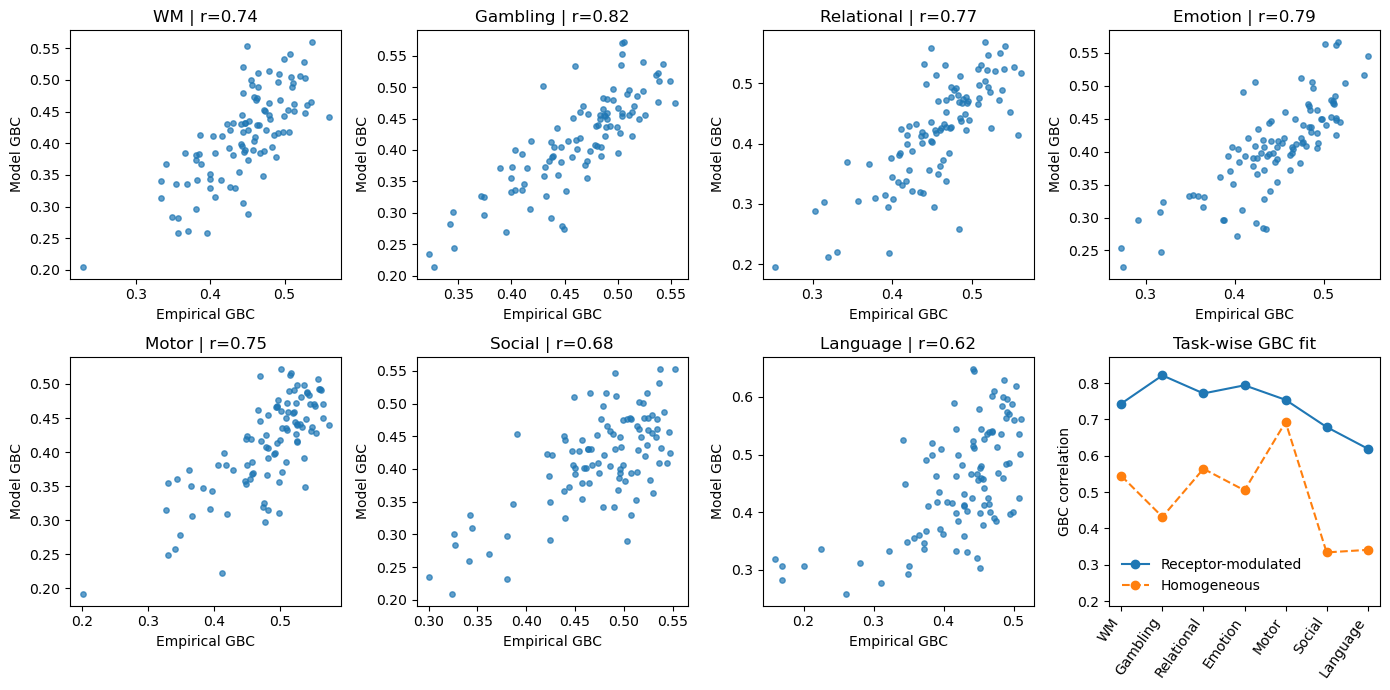

In [8]:
# Cell 8: plot receptor weights and seven-task GBC predictions

receptor_index = {name: i for i, name in enumerate(RECEPTOR_NAMES)}
weight_matrix = np.column_stack([TASK_RESULTS[task]["weights"] for task in TASKS])
weight_matrix = weight_matrix[[receptor_index[name] for name, _ in PAPER_RECEPTORS]]

# Normalize each task because positive weight scaling leaves min-max-derived eta unchanged.
weight_scale = np.max(np.abs(weight_matrix), axis=0, keepdims=True)
weight_matrix /= np.where(weight_scale > 0, weight_scale, 1.0)

# Flip the first six columns for visual comparison with the NEMO weight-sign convention only.
weight_matrix[:, :6] *= -1

fig, ax = plt.subplots(figsize=(7.5, 8.5))
im = ax.imshow(weight_matrix, cmap="RdBu", vmin=-1.0, vmax=1.0, aspect="auto")
ax.set_xticks(range(len(TASKS)), [TASK_LABELS[task] for task in TASKS], rotation=55, ha="right")
ax.set_yticks(range(len(PAPER_RECEPTORS)), [label for _, label in PAPER_RECEPTORS])
ax.set_title("NEMO-style receptor weights")
fig.colorbar(im, ax=ax, label="Weight", fraction=0.035, pad=0.03)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, task in zip(axes.flat[:7], TASKS):
    emp = compute_gbc_from_fc(TASK_FC[task])
    model = compute_gbc_from_fc(TASK_RESULTS[task]["model_fc"])
    ax.scatter(emp, model, s=15, alpha=0.7)
    ax.set_title(f"{TASK_LABELS[task]} | r={TASK_RESULTS[task]['gbc_r']:.2f}")
    ax.set_xlabel("Empirical GBC")
    ax.set_ylabel("Model GBC")

ax = axes.flat[7]
x = np.arange(len(TASKS))
ax.plot(x, gbc_values, "o-", label="Receptor-modulated")
ax.plot(x, baseline_values, "o--", label="Homogeneous")
ax.set_xticks(x, [TASK_LABELS[task] for task in TASKS], rotation=55, ha="right")

all_gbc = np.r_[gbc_values, baseline_values]
span = np.ptp(all_gbc)
lower_pad = max(0.10, 0.30 * span)
upper_pad = max(0.05, 0.10 * span)
ax.set_ylim(
    max(-1.0, all_gbc.min() - lower_pad),
    min(1.0, all_gbc.max() + upper_pad),
)

ax.set_ylabel("GBC correlation")
ax.set_title("Task-wise GBC fit")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

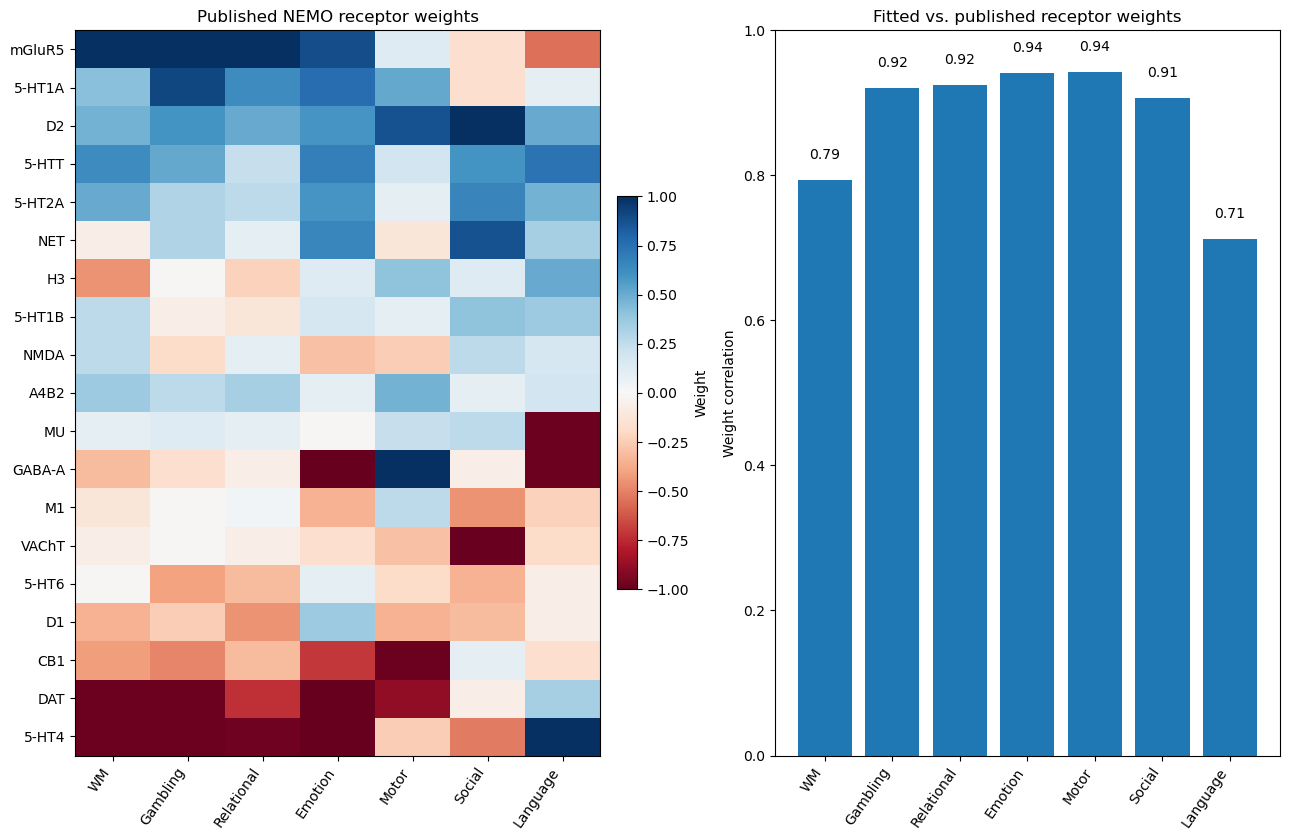

In [9]:
# Cell 9: compare fitted receptor weights with the published NEMO weight pattern

# Approximate values digitized from the published heatmap and normalized so each task has max |weight| = 1.
paper_weight_matrix = np.array([
    [ 1.00,  1.00,  1.00,  0.89,  0.13, -0.17, -0.55],  # mGluR5
    [ 0.42,  0.91,  0.63,  0.76,  0.51, -0.17,  0.09],  # 5-HT1A
    [ 0.47,  0.60,  0.50,  0.59,  0.87,  1.00,  0.50],  # D2
    [ 0.63,  0.51,  0.23,  0.68,  0.19,  0.60,  0.74],  # 5-HTT
    [ 0.50,  0.30,  0.26,  0.59,  0.09,  0.66,  0.47],  # 5-HT2A
    [-0.07,  0.30,  0.09,  0.65, -0.12,  0.87,  0.33],  # NET
    [-0.45, -0.01, -0.23,  0.13,  0.40,  0.13,  0.50],  # H3
    [ 0.26, -0.07, -0.12,  0.17,  0.09,  0.40,  0.36],  # 5-HT1B
    [ 0.26, -0.18,  0.09, -0.29, -0.25,  0.26,  0.17],  # NMDA
    [ 0.36,  0.26,  0.33,  0.09,  0.47,  0.09,  0.19],  # A4B2
    [ 0.09,  0.13,  0.09, -0.01,  0.23,  0.26, -0.98],  # MU
    [-0.32, -0.17, -0.07, -1.00,  1.00, -0.07, -0.98],  # GABA-A
    [-0.12, -0.01,  0.03, -0.35,  0.26, -0.45, -0.23],  # M1
    [-0.07, -0.01, -0.07, -0.17, -0.29, -0.99, -0.18],  # VAChT
    [-0.01, -0.40, -0.32,  0.09, -0.18, -0.35, -0.07],  # 5-HT6
    [-0.35, -0.25, -0.45,  0.36, -0.35, -0.32, -0.07],  # D1
    [-0.42, -0.49, -0.32, -0.71, -0.98,  0.09, -0.17],  # CB1
    [-0.98, -0.98, -0.73, -1.00, -0.89, -0.07,  0.33],  # DAT
    [-0.98, -0.98, -0.97, -1.00, -0.25, -0.52,  1.00],  # 5-HT4
])

weight_correlations = np.array([
    np.corrcoef(weight_matrix[:, i], paper_weight_matrix[:, i])[0, 1]
    for i in range(len(TASKS))
])

fig, axes = plt.subplots(1, 2, figsize=(13, 8.5), gridspec_kw={"width_ratios": [1.0, 0.9]})

ax = axes[0]
im = ax.imshow(paper_weight_matrix, cmap="RdBu", vmin=-1.0, vmax=1.0, aspect="auto")
ax.set_xticks(range(len(TASKS)), [TASK_LABELS[task] for task in TASKS], rotation=55, ha="right")
ax.set_yticks(range(len(PAPER_RECEPTORS)), [label for _, label in PAPER_RECEPTORS])
ax.set_title("Published NEMO receptor weights")
fig.colorbar(im, ax=ax, label="Weight", fraction=0.035, pad=0.03)

ax = axes[1]
x = np.arange(len(TASKS))
ax.bar(x, weight_correlations)
ax.set_xticks(x, [TASK_LABELS[task] for task in TASKS], rotation=55, ha="right")
ax.set_ylabel("Weight correlation")
ax.set_title("Fitted vs. published receptor weights")
ax.set_ylim(min(0, weight_correlations.min() - 0.1), 1.0)
for i, r in enumerate(weight_correlations):
    ax.text(i, r + 0.025, f"{r:.2f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()